In [1]:
import pandas as pd

# Load Dataset
df = pd.read_csv("School_data.csv")

print(df.head())

# Data Preprocessing
df = df.dropna()




  School_ID    District     Block Urban_Rural  %_Math_Score  %_Language_Score  \
0     SCH_1  District_C  Block_C1       Rural         43.32             48.87   
1     SCH_2  District_A  Block_A3       Rural         81.98             83.18   
2     SCH_3  District_B  Block_B1       Rural         44.68             46.38   
3     SCH_4  District_A  Block_A1       Urban         44.86             35.20   
4     SCH_5  District_C  Block_C1       Rural         47.41             47.94   

   %_Science_Score  Teacher_Student_Ratio  Avg_Teacher_Experience_Years  \
0            48.89                   40.1                           5.7   
1            83.26                    NaN                           5.8   
2            40.19                   29.9                           7.1   
3            47.77                   24.6                           2.6   
4            50.99                   39.8                           6.1   

   Teacher_Trainings_Attended  Electricity_Available  Internet

Accuracy: 0.5067307692307692


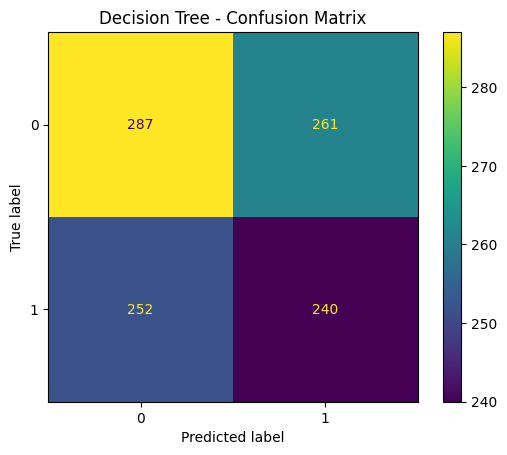


Classification Report:

              precision    recall  f1-score   support

           0       0.53      0.52      0.53       548
           1       0.48      0.49      0.48       492

    accuracy                           0.51      1040
   macro avg       0.51      0.51      0.51      1040
weighted avg       0.51      0.51      0.51      1040



In [2]:
import numpy as np

df = pd.read_csv('School_data.csv')
df['Performance_Class'] = np.where(df['%_Math_Score'] >= 60, 1, 0)


# ================= Decision Tree Algorithm =================

import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

# Features & target
X = df[['Teacher_Student_Ratio','Parent_Literacy_Rate',
        'Internet_Available','Avg_Teacher_Experience_Years']]

y = df['Performance_Class']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Decision Tree - Confusion Matrix")
plt.show()

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Prediction for 70 literacy: [60.47013983]


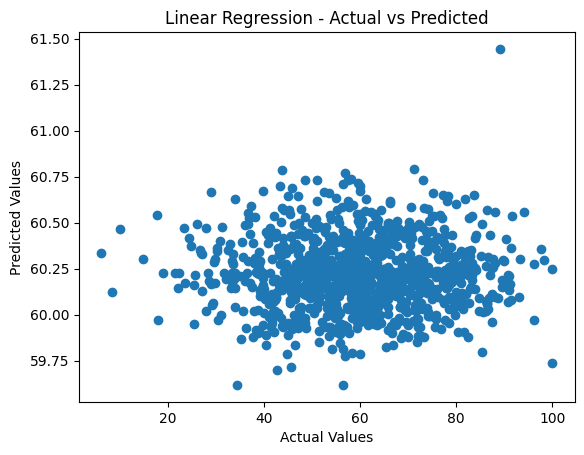

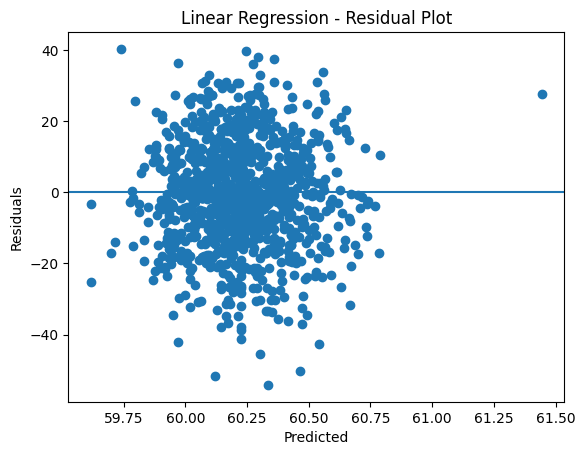

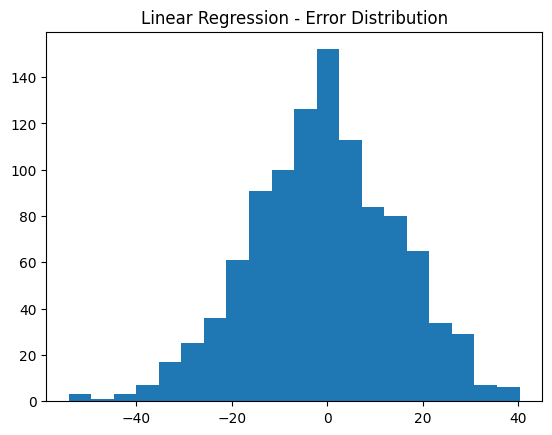

Linear Regression MAE: 11.908848366267655


In [3]:
# ================= Simple Linear Regression =================


import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split

# Load dataset
df = pd.read_csv('School_data.csv')

# Fill missing values
df['Parent_Literacy_Rate'] = df['Parent_Literacy_Rate'].fillna(
    df['Parent_Literacy_Rate'].mean()
)

df['%_Math_Score'] = df['%_Math_Score'].fillna(
    df['%_Math_Score'].mean()
)

# Features and target
X = df[['Parent_Literacy_Rate']]
y = df['%_Math_Score']

# Train-Test Split 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Prediction on TEST DATA (NOT single value)
y_pred_lr = model.predict(X_test)

# Single prediction (optional)
sample_data = pd.DataFrame({'Parent_Literacy_Rate': [70]})
prediction = model.predict(sample_data)
print("Prediction for 70 literacy:", prediction)

# ------------------ GRAPHS ------------------

# Actual vs Predicted
plt.figure()
plt.scatter(y_test, y_pred_lr)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Linear Regression - Actual vs Predicted")
plt.show()

# Residual Plot
residuals_lr = y_test - y_pred_lr
plt.figure()
plt.scatter(y_pred_lr, residuals_lr)
plt.axhline(y=0)
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Linear Regression - Residual Plot")
plt.show()

#Error Distribution
plt.figure()
plt.hist(residuals_lr, bins=20)
plt.title("Linear Regression - Error Distribution")
plt.show()

# MAE
print("Linear Regression MAE:", mean_absolute_error(y_test, y_pred_lr))

In [4]:
# ================= Multiple Linear Regression =================


from sklearn.linear_model import LinearRegression

# Load dataset
df = pd.read_csv("School_data.csv")

# Fill missing values
df = df.fillna(df.mean(numeric_only=True))

# Features
X = df[['Teacher_Student_Ratio',
        'Parent_Literacy_Rate',
        'Avg_Teacher_Experience_Years']]

# Target
y = df['%_Science_Score']

# Train model
model = LinearRegression()
model.fit(X, y)

# Proper prediction input
sample_data = pd.DataFrame({
    'Teacher_Student_Ratio': [30],
    'Parent_Literacy_Rate': [70],
    'Avg_Teacher_Experience_Years': [10]
})

# Predict
prediction = model.predict(sample_data)

print("Prediction:", prediction)

Prediction: [61.22598607]


In [5]:
# ================= Logistic Regression =================


from sklearn.linear_model import LogisticRegression

# Load dataset
df = pd.read_csv('School_data.csv')

# Fill missing values
df = df.fillna(df.mean(numeric_only=True))

# Create classification target
df['Performance_Class'] = (df['%_Math_Score'] >= 60).astype(int)

# Features
X = df[['Internet_Available',
        'Parent_Literacy_Rate'
        ]]

# Target
y = df['Performance_Class']

# Create model
model = LogisticRegression()

# Train model
model.fit(X, y)

# Predict
print(model.predict(X.head()))

[1 1 1 1 1]


Accuracy: 0.7346153846153847


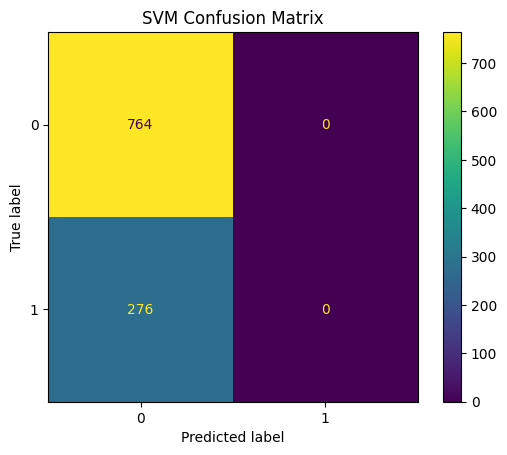

In [6]:
# ================= Support Vector Machine =================

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler

# Load data
df = pd.read_csv('School_data.csv')
df = df.fillna(df.mean(numeric_only=True))

# Target (Urban=1, Rural=0)
df['Area_Class'] = (df['Internet_Available'] == 1).astype(int)

# Features & target
X = df[['Teacher_Student_Ratio','Parent_Literacy_Rate','Avg_Teacher_Experience_Years']]
y = df['Area_Class']

# Scale + split
scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Model
model = SVC(kernel='linear')
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Confusion Matrix
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred)).plot()
plt.title("SVM Confusion Matrix")
plt.show()

In [1]:
# ================= KNN Algorithm =================

import pandas as pd
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Load dataset
df = pd.read_csv('School_data.csv')

# Fill missing values
df = df.fillna(df.mean(numeric_only=True))

# Create target
df['Performance_Class'] = (df['%_Math_Score'] >= 60).astype(int)

# Features and target
X = df[['Teacher_Student_Ratio',
        'Parent_Literacy_Rate']]

y = df['Performance_Class']

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create model
model = KNeighborsClassifier(n_neighbors=5)

# Train
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))


Accuracy: 0.5134615384615384


In [2]:
# ================= Naive Bayes Algorithm =================

from sklearn.naive_bayes import GaussianNB

X = df[['Internet_Available','Functional_Toilets',
        'Library_Available']]
y = df['Performance_Class']

model = GaussianNB()
model.fit(X,y)

print(model.predict(X.head()))


[1 1 1 1 1]


In [3]:
# ================= Association Rule Algorithm =================

import pandas as pd
from mlxtend.frequent_patterns import apriori, association_rules

# Load dataset
df = pd.read_csv('School_data.csv')

# Fill missing values
df = df.fillna(df.mean(numeric_only=True))

# Select columns
basket = df[['Electricity_Available',
             'Internet_Available',
             'Library_Available']]

# Convert to Boolean
basket = basket.astype(bool)

# Apply Apriori
freq = apriori(
    basket,
    min_support=0.2,
    use_colnames=True
)

# Generate rules
rules = association_rules(
    freq,
    metric='confidence',
    min_threshold=0.5
)

# Display output
print(rules.head())

                       antecedents                         consequents  \
0  frozenset({Internet_Available})  frozenset({Electricity_Available})   
1   frozenset({Library_Available})  frozenset({Electricity_Available})   

   antecedent support  consequent support   support  confidence      lift  \
0            0.330577            0.895577  0.292500    0.884817  0.987985   
1            0.483462            0.895577  0.432692    0.894988  0.999342   

   representativity  leverage  conviction  zhangs_metric   jaccard  certainty  \
0               1.0 -0.003557    0.906582      -0.017842  0.313285  -0.103044   
1               1.0 -0.000285    0.994392      -0.001272  0.457224  -0.005639   

   kulczynski  
0    0.605711  
1    0.689066  
